In [ ]:
# --- Run this cell only ONCE per session ---

# 1. Install Dependencies
print("Installing the required 'resampy' library...")
!pip install -q resampy
print("✅ Installation complete.")

# 2. Import Libraries
import os
import zipfile
import librosa
import numpy as np
import time
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Conv1D, MaxPooling1D, LSTM
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# 3. Mount Google Drive
print("\nMounting Google Drive...")
try:
    drive.mount('/content/drive', force_remount=True)
    print("✅ Drive mounted successfully.")
except Exception as e:
    print(f"🚨 Error mounting drive: {e}")
    raise

# 4. Unzip the Dataset
# 🔴 IMPORTANT: Update this path to where your archive.zip is located in Google Drive
zip_file_path = '/content/drive/MyDrive/ravdesszip.zip' # Corrected filename
extract_dir = '/content/drive/MyDrive/'

print(f"\nUnzipping '{zip_file_path}'...")
# Check if the target extraction directory exists, if not create it
if not os.path.exists(extract_dir):
    os.makedirs(extract_dir)
    print(f"Created extraction directory: {extract_dir}")

# Check if the zip file exists before attempting to unzip
if not os.path.exists(zip_file_path):
    print(f"🚨 ERROR: The file '{zip_file_path}' was not found.")
    print("Please make sure you have uploaded ravdesszip.zip and the path is correct.")
    raise FileNotFoundError(f"Zip file not found at {zip_file_path}")

# Check if the dataset is already unzipped by looking for a known file/folder
# Assuming 'Actor_01' is always present in the unzipped dataset
dataset_already_unzipped = False
for root, dirs, files in os.walk(extract_dir):
    if 'Actor_01' in dirs:
        dataset_already_unzipped = True
        break

if not dataset_already_unzipped:
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
        print("✅ Unzipping complete.")
    except Exception as e:
        print(f"🚨 Error during unzipping: {e}")
        raise
else:
    print("✅ Dataset already unzipped.")


# 5. Find the Correct Data Path
def find_dataset_folder(base_path):
    """Recursively searches for the RAVDESS dataset folder."""
    print(f"Searching for dataset folder within: {base_path}")
    for dirpath, dirnames, filenames in os.walk(base_path):
        # Check if both 'Actor_01' and 'Actor_24' are present in the current directory's subdirectories
        if 'Actor_01' in dirnames and 'Actor_24' in dirnames:
            print(f"✅ Dataset folder found at: {dirpath}")
            return dirpath
    return None

DATA_PATH = find_dataset_folder(extract_dir)
if DATA_PATH is None:
    print("🚨 ERROR: Could not automatically locate the RAVDESS dataset folder after unzipping.")
    print(f"Please manually verify the contents of '{extract_dir}' and update the DATA_PATH variable.")
    raise FileNotFoundError("Dataset folder not found.")

Installing the required 'resampy' library...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 65.3 MB/s eta 0:00:00
✅ Installation complete.

Mounting Google Drive...
Mounted at /content/drive
✅ Drive mounted successfully.

Unzipping '/content/drive/MyDrive/ravdesszip.zip'...
✅ Unzipping complete.
Searching for dataset folder within: /content/drive/MyDrive/
✅ Dataset folder found at: /content/drive/MyDrive/


In [ ]:
# Re-import necessary libraries in case of kernel restart
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# --- Run this cell to load, augment, and prepare your data ---

# 1. Install augmentation library
print("Installing 'audiomentations' library...")
!pip install -q audiomentations
print("✅ Installation complete.")
from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift, Shift
import tqdm # Import tqdm for the progress bar

# 2. Define the Augmentation Pipeline
augment = Compose([
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.5),
    TimeStretch(min_rate=0.8, max_rate=1.25, p=0.5),
    PitchShift(min_semitones=-4, max_semitones=4, p=0.5),
    Shift(min_shift=-0.5, max_shift=0.5, p=0.5), # Changed min_fraction and max_fraction to min_shift and max_shift
])

# 3. Load Raw Audio Waves and Labels
def load_raw_data(data_path):
    raw_data = []
    labels = []
    emotion_map = { '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad', '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised' }
    start_time = time.time()
    print("\nLoading raw audio files...")
    global initial_sample_rate
    initial_sample_rate = None

    all_files = []
    for actor_folder in sorted(os.listdir(data_path)):
        if actor_folder.startswith('Actor_'):
            actor_path = os.path.join(data_path, actor_folder)
            for file_name in os.listdir(actor_path):
                if file_name.endswith('.wav'): # Ensure only process audio files
                     all_files.append(os.path.join(actor_path, file_name))


    for file_path in tqdm.tqdm(all_files, desc="Processing audio files"):
        try:
            file_name = os.path.basename(file_path)
            emotion_code = file_name.split('-')[2]
            emotion = emotion_map[emotion_code]
            audio_data, sample_rate = librosa.load(file_path, sr=None) # Load at original sample rate
            if initial_sample_rate is None:
                initial_sample_rate = sample_rate
            raw_data.append(audio_data)
            labels.append(emotion)
        except Exception as e: # Catching a broader Exception for robustness
            print(f"\nWarning: Could not process file {file_name}. Error: {e}")
            continue # Skip to the next file if an error occurs

    print(f"\n✅ Raw data loading completed in {time.time() - start_time:.2f} seconds.")
    return raw_data, np.array(labels)

X_raw, y_raw = load_raw_data(DATA_PATH)
if len(X_raw) == 0:
    raise ValueError("No audio data was loaded.")

# 4. Prepare Labels and Split Data BEFORE Feature Extraction
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)
y_categorical = to_categorical(y_encoded)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y_categorical, test_size=0.2, random_state=42, stratify=y_categorical)

# 5. Apply Augmentation to the Training Set
print("\nAugmenting training data... (This may take a moment)")
X_train_augmented_audio = []
y_train_augmented = []
for i, audio in tqdm.tqdm(enumerate(X_train_raw), total=len(X_train_raw), desc="Augmenting training data"):
    # Add original audio
    X_train_augmented_audio.append(audio)
    y_train_augmented.append(y_train[i])

    # Add augmented audio
    augmented_audio = augment(samples=audio, sample_rate=initial_sample_rate)
    X_train_augmented_audio.append(augmented_audio)
    y_train_augmented.append(y_train[i])
print(f"\n✅ Augmentation complete. Training set size doubled to {len(X_train_augmented_audio)} samples.")

# 6. Extract MFCCs from ALL audio clips
def extract_features(audio_list):
    feature_list = []
    for audio in tqdm.tqdm(audio_list, desc="Extracting features"):
        mfccs = librosa.feature.mfcc(y=audio, sr=initial_sample_rate, n_mfcc=40)
        feature_list.append(mfccs)
    return feature_list

print("\nExtracting features from all datasets...")
X_train_features = extract_features(X_train_augmented_audio)
X_test_features = extract_features(X_test_raw)
print("\n✅ Feature extraction complete.")


# 7. Pad and Finalize Data Preparation
y_train_augmented = np.array(y_train_augmented)
max_pad_len = max(x.shape[1] for x in X_train_features + X_test_features)

def pad_features(features, max_len):
    padded = np.array([np.pad(feat, ((0, 0), (0, max_len - feat.shape[1])), mode='constant') for feat in features])
    return padded

print("\nPadding features...")
X_train_padded = pad_features(X_train_features, max_pad_len)
X_test_padded = pad_features(X_test_features, max_pad_len)
X_train_padded = X_train_padded.transpose((0, 2, 1))
X_test_padded = X_test_padded.transpose((0, 2, 1))

print("✅ Data is ready for training.")
print(f"Augmented training data shape: {X_train_padded.shape}")
print(f"Test data shape: {X_test_padded.shape}")


Installing 'audiomentations' library...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 21.5 MB/s eta 0:00:00
✅ Installation complete.

Loading raw audio files...


Processing audio files: 100%|██████████| 1440/1440 [00:26<00:00, 54.39it/s] 



✅ Raw data loading completed in 26.51 seconds.

Augmenting training data... (This may take a moment)


Augmenting training data: 100%|██████████| 1152/1152 [01:26<00:00, 13.27it/s]



✅ Augmentation complete. Training set size doubled to 2304 samples.

Extracting features from all datasets...


Extracting features: 100%|██████████| 288/288 [00:07<00:00, 37.68it/s]



✅ Feature extraction complete.

Padding features...
✅ Data is ready for training.
Augmented training data shape: (2304, 495, 40)
Test data shape: (288, 495, 40)


In [ ]:
# --- This cell builds and trains the high-performance model ---

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Activation, BatchNormalization
import tensorflow as tf
from sklearn.metrics import f1_score, precision_score, recall_score

# 1. Build the Deeper CNN/LSTM Model
model = Sequential([
    Conv1D(512, 5, padding='same', input_shape=(X_train_padded.shape[1], X_train_padded.shape[2])),
    Activation('relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=4),
    Dropout(0.2),

    Conv1D(512, 5, padding='same'),
    Activation('relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=4),
    Dropout(0.2),

    Conv1D(512, 5, padding='same'),
    Activation('relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=4),
    Dropout(0.2),

    LSTM(128),
    Dropout(0.3),

    Dense(y_categorical.shape[1], activation='softmax')
])
model.summary()

# 2. Compile the Model
opt = Adam(learning_rate=0.0001)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

# 3. Define Callbacks
model_checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_accuracy', mode='max', verbose=1)
early_stopping = EarlyStopping(monitor='val_accuracy', patience=15, verbose=1, restore_best_weights=True)

# 4. Train the Model
print("\n--- Starting Training for the High-Performance Model ---")
history = model.fit(X_train_padded, y_train_augmented,
                    batch_size=32,
                    epochs=100,
                    validation_data=(X_test_padded, y_test),
                    callbacks=[model_checkpoint, early_stopping],
                    verbose=2)
print("--- Model Training Finished ---\n")

# 5. Evaluate the Best Model
print("Evaluating the best performing model from the training run...")
score = model.evaluate(X_test_padded, y_test, verbose=0)
print(f"Final Test Accuracy (Best Model): {score[1]*100:.2f}%")

# 6. Calculate and Print Additional Metrics
y_pred_probs = model.predict(X_test_padded)
y_pred_classes = tf.argmax(y_pred_probs, axis=1)
y_true_classes = tf.argmax(y_test, axis=1)

f1 = f1_score(y_true_classes, y_pred_classes, average='weighted')
precision = precision_score(y_true_classes, y_pred_classes, average='weighted')
recall = recall_score(y_true_classes, y_pred_classes, average='weighted')

print(f"F1 Score (weighted): {f1:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 495, 512)       │       102,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 495, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 495, 512)       │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 123, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 123, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 123, 512)       │     1,311,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 123, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 123, 512)       │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 30, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 30, 512)        │     1,311,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 30, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 7, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       328,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,060,744 (11.68 MB)

 Trainable params: 3,057,672 (11.66 MB)

 Non-trainable params: 3,072 (12.00 KB)


--- Starting Training for the High-Performance Model ---
Epoch 1/100

Epoch 1: val_accuracy improved from -inf to 0.23611, saving model to best_model.keras
72/72 - 105s - 1s/step - accuracy: 0.2344 - loss: 1.9554 - val_accuracy: 0.2361 - val_loss: 1.9708
Epoch 2/100

Epoch 2: val_accuracy improved from 0.23611 to 0.29861, saving model to best_model.keras
72/72 - 140s - 2s/step - accuracy: 0.3181 - loss: 1.7305 - val_accuracy: 0.2986 - val_loss: 1.8221
Epoch 3/100

Epoch 3: val_accuracy improved from 0.29861 to 0.42361, saving model to best_model.keras
72/72 - 140s - 2s/step - accuracy: 0.3633 - loss: 1.6176 - val_accuracy: 0.4236 - val_loss: 1.6060
Epoch 4/100

Epoch 4: val_accuracy improved from 0.42361 to 0.43750, saving model to best_model.keras
72/72 - 146s - 2s/step - accuracy: 0.4293 - loss: 1.5143 - val_accuracy: 0.4375 - val_loss: 1.4633
Epoch 5/100

Epoch 5: val_accuracy improved from 0.43750 to 0.45833, saving model to best_model.keras
72/72 - 97s - 1s/step - accuracy: 0.491

9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 864ms/step


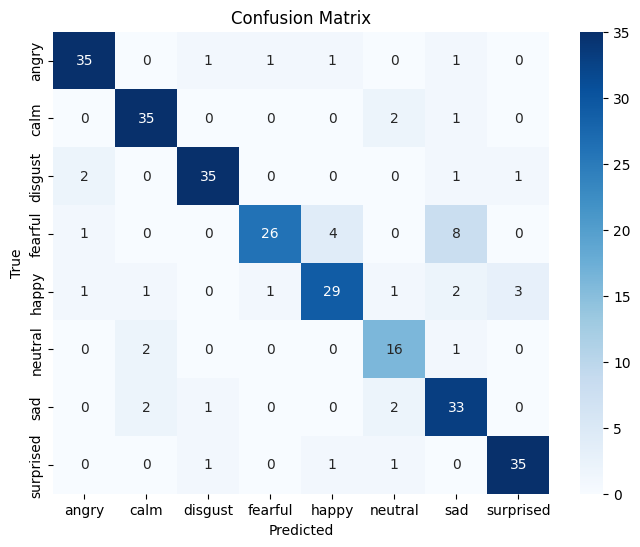

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


# Get predictions
y_pred = model.predict(X_test_padded)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


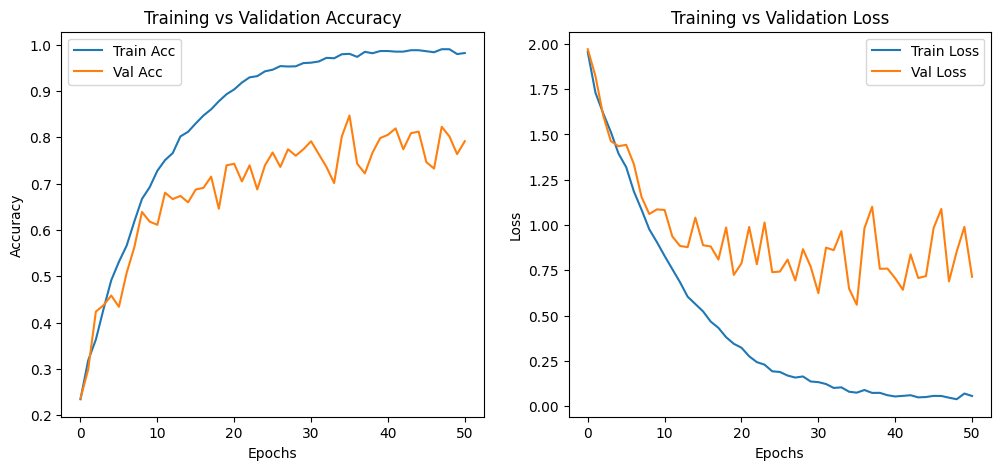

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy/loss
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')

plt.show()


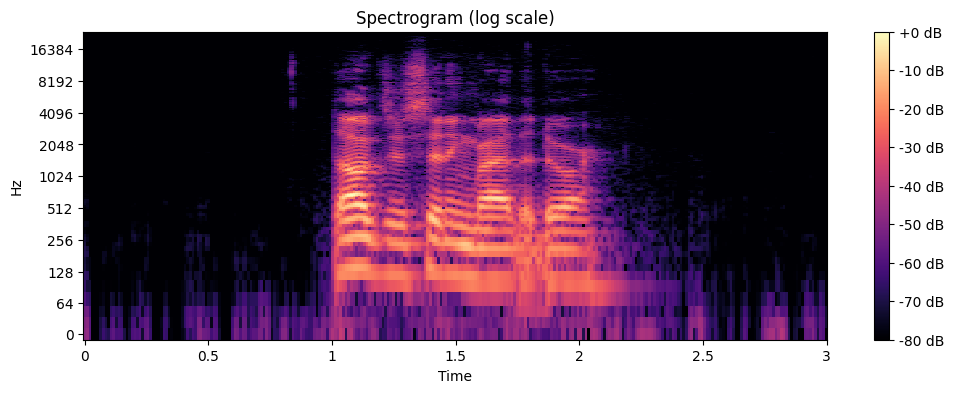

In [ ]:
import librosa.display

# Pick one raw audio sample from training
sample_audio = X_train_raw[0]
plt.figure(figsize=(12, 4))
D = librosa.amplitude_to_db(np.abs(librosa.stft(sample_audio)), ref=np.max)
librosa.display.specshow(D, sr=initial_sample_rate, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title("Spectrogram (log scale)")
plt.show()


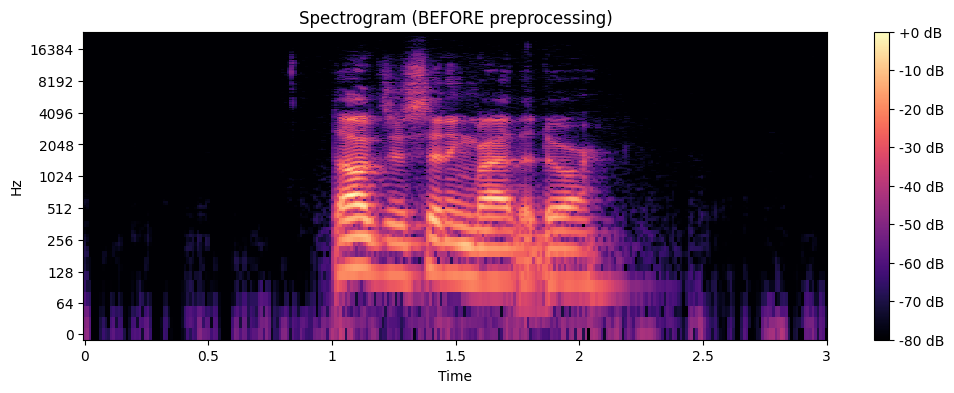

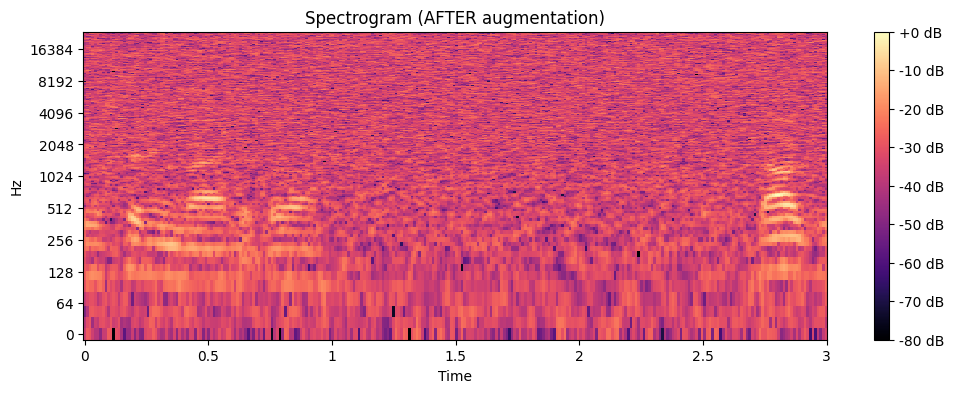

In [ ]:
# Select a raw audio sample
sample_audio = X_train_raw[0]

# --- Spectrogram BEFORE preprocessing ---
plt.figure(figsize=(12, 4))
D_raw = librosa.amplitude_to_db(np.abs(librosa.stft(sample_audio)), ref=np.max)
librosa.display.specshow(D_raw, sr=initial_sample_rate, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title("Spectrogram (BEFORE preprocessing)")
plt.show()

# --- Apply augmentation pipeline ---
# Ensure initial_sample_rate is defined from the data loading step
if 'initial_sample_rate' not in globals():
    print("Error: initial_sample_rate is not defined. Please run the data loading cell first.")
else:
    augmented_audio = augment(samples=sample_audio, sample_rate=initial_sample_rate)

    # --- Spectrogram AFTER preprocessing (augmentation) ---
    plt.figure(figsize=(12, 4))
    D_augmented = librosa.amplitude_to_db(np.abs(librosa.stft(augmented_audio)), ref=np.max)
    librosa.display.specshow(D_augmented, sr=initial_sample_rate, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')
    plt.title("Spectrogram (AFTER augmentation)")
    plt.show()

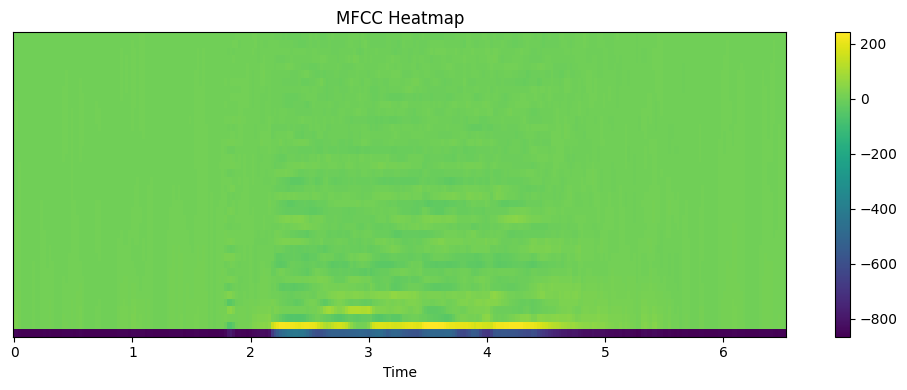

In [ ]:
# Extract MFCC for visualization
mfcc = librosa.feature.mfcc(y=sample_audio, sr=initial_sample_rate, n_mfcc=40)
plt.figure(figsize=(10, 4))
librosa.display.specshow(mfcc, x_axis='time', cmap='viridis')
plt.colorbar()
plt.title("MFCC Heatmap")
plt.tight_layout()
plt.show()


In [ ]:
# Define the path to save the model in Google Drive
model_save_path = '/content/drive/MyDrive/ravdess_model.h5'

# Save the model to the specified path
model.save(model_save_path)

print(f"Model saved successfully to: {model_save_path}")

Model saved successfully to: /content/drive/MyDrive/ravdess_model.h5


# Task
Generate and display the spectrogram of an audio file before and after removing leading and trailing silence.

## Load audio

### Subtask:
Load an example audio file.


## Visualize original spectrogram

### Subtask:
Generate and display the spectrogram of the original audio.


**Reasoning**:
Generate and display the spectrogram of the original audio data using librosa.



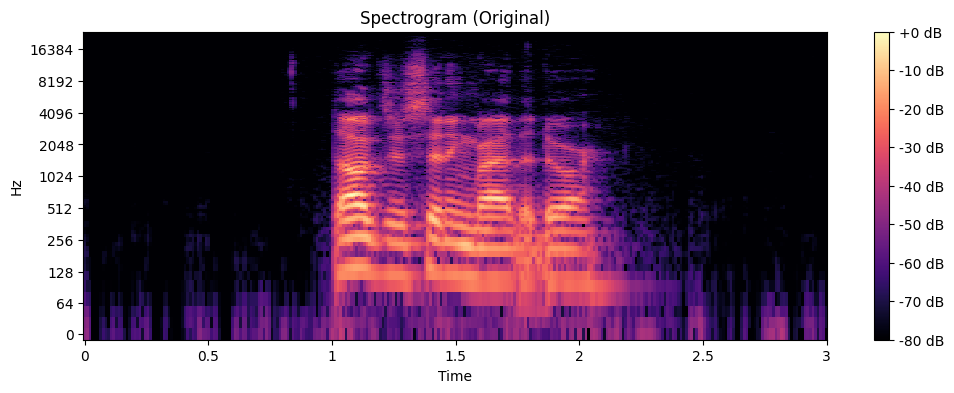

In [ ]:
plt.figure(figsize=(12, 4))
D_raw = librosa.amplitude_to_db(np.abs(librosa.stft(sample_audio)), ref=np.max)
librosa.display.specshow(D_raw, sr=initial_sample_rate, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title("Spectrogram (Original)")
plt.show()

**Reasoning**:
Remove leading and trailing silence from the audio using librosa.effects.trim.



In [ ]:
trimmed_audio, index = librosa.effects.trim(sample_audio)

**Reasoning**:
Generate and display the spectrogram of the trimmed audio as requested by the subtask instructions.



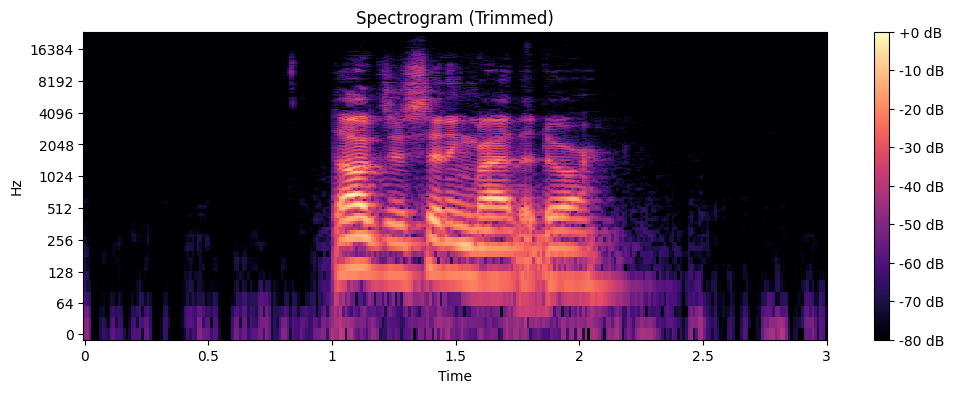

In [ ]:
plt.figure(figsize=(12, 4))
D_trimmed = librosa.amplitude_to_db(np.abs(librosa.stft(trimmed_audio)), ref=np.max)
librosa.display.specshow(D_trimmed, sr=initial_sample_rate, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title("Spectrogram (Trimmed)")
plt.show()

## Compare

### Subtask:
Briefly describe the difference observed in the two spectrograms.


## Summary:

### Data Analysis Key Findings

*   The original spectrogram showed low-amplitude regions at the beginning and end, representing leading and trailing silence.
*   The trimmed spectrogram, generated after removing silence using `librosa.effects.trim`, did not show these low-amplitude regions at the start and end.

### Insights or Next Steps

*   Trimming silence effectively removes non-essential parts of the audio, resulting in a more focused spectrogram visualization of only the audible content.
